In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv) 
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
titanic_train = pd.read_csv('/kaggle/input/titanic/train.csv')
titanic_test = pd.read_csv('/kaggle/input/titanic/test.csv') 

In [3]:
titanic_train.shape 

(891, 12)

In [4]:
titanic_test.shape 

(418, 11)

In [5]:
titanic_train['Survived'].value_counts() 

0    549
1    342
Name: Survived, dtype: int64

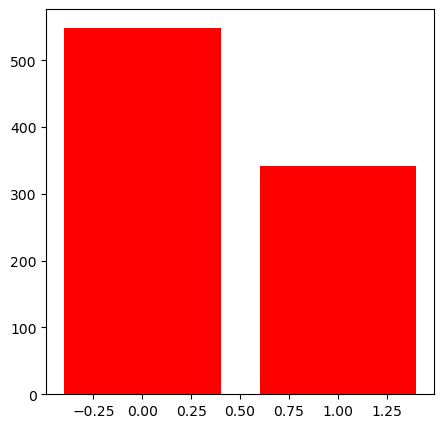

In [6]:
plt.figure(figsize=(5,5)) 
plt.bar(list(titanic_train['Survived'].value_counts().keys()),list(titanic_train['Survived'].value_counts()), color="r") 
plt.show() 

In [7]:
titanic_train['Sex'].value_counts() 

male      577
female    314
Name: Sex, dtype: int64

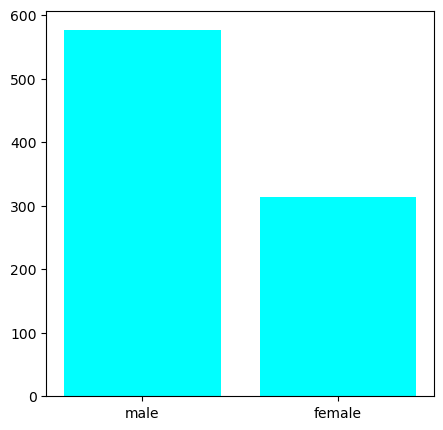

In [8]:
plt.figure(figsize=(5,5)) 
plt.bar(list(titanic_train['Sex'].value_counts().keys()),list(titanic_train['Sex'].value_counts()), color="cyan") 
plt.show() 

In [9]:
titanic_train['Pclass'].value_counts() 

3    491
1    216
2    184
Name: Pclass, dtype: int64

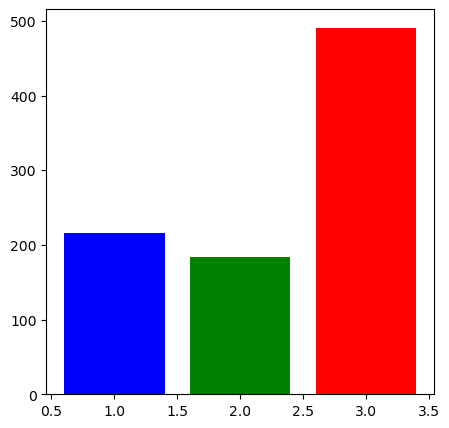

In [10]:
plt.figure(figsize=(5,5)) 
plt.bar(list(titanic_train['Pclass'].value_counts().keys()),list(titanic_train['Pclass'].value_counts()), color=["red","blue","green"]) 
plt.show() 

In [11]:
titanic_train.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
titanic_train = titanic_train.dropna()

In [13]:
titanic_train.isnull().sum() 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [14]:
x_train = titanic_train[['Age']]
y_train = titanic_train[['Survived']] 

In [15]:
from sklearn.tree import DecisionTreeClassifier 

In [16]:
dtc = DecisionTreeClassifier()

In [17]:
dtc.fit(x_train,y_train) 

DecisionTreeClassifier()

In [18]:
# Predicting Values 
titanic_test.isnull().sum()  

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [19]:
titanic_test = titanic_test.dropna() 

In [20]:
x_test = titanic_test[['Age']] 

In [21]:
y_pred = dtc.predict(x_test) 

In [22]:
y_pred 

array([1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1])

In [23]:
final = pd.DataFrame(y_pred)

In [24]:
final.to_csv("titanic_comp.csv")  